In [1]:
import kagglehub

path = kagglehub.dataset_download("ashydv/advertising-dataset")

print(path)

Using Colab cache for faster access to the 'advertising-dataset' dataset.
/kaggle/input/advertising-dataset


In [2]:
import os

print(os.listdir(path))

['advertising.csv']


In [3]:
import pandas as pd
import os

file_path = os.path.join(path, "advertising.csv")

df = pd.read_csv(file_path)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.shape

(200, 4)

In [5]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


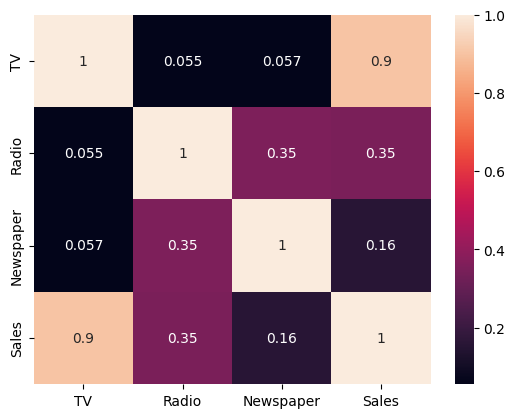

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df.corr(),
    annot=True
)

plt.show()

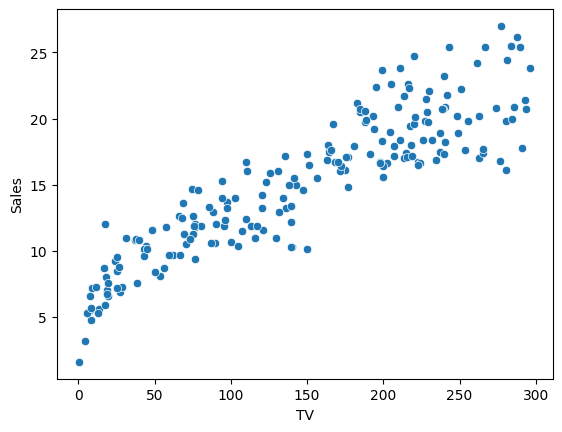

In [10]:
sns.scatterplot(
    x="TV",
    y="Sales",
    data=df
)

plt.show()

In [11]:
X = df[
    [
        "TV",
        "Radio",
        "Newspaper"
    ]
]

y = df["Sales"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [15]:
predictions = model.predict(
    X_test
)

predictions[:5]

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879])

In [16]:
from sklearn.metrics import r2_score

score = r2_score(
    y_test,
    predictions
)

print("R2 Score =", score)

R2 Score = 0.9059011844150826


In [17]:
sample = [[230, 37, 69]]

prediction = model.predict(sample)

print(prediction)

[21.28546573]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


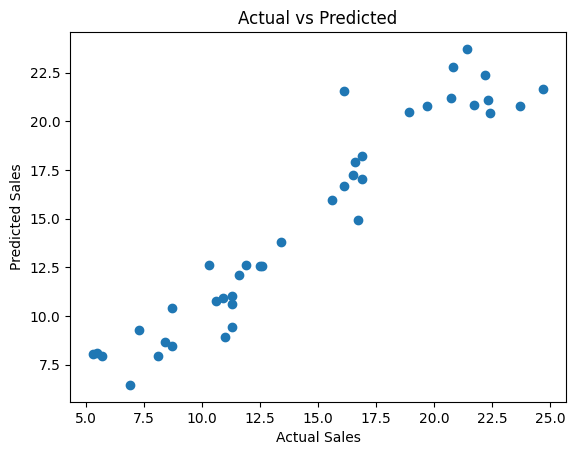

In [18]:
plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.show()